# Energy-Based Transformer on a Real Reasoning Dataset

This notebook trains and inspects the actual public Energy-Based Transformer NLP implementation from `alexiglad/EBT`, using a real dataset instead of hand-written thesis notes.

The default dataset is GSM8K. That choice is intentional: GSM8K examples contain a question and a multi-step answer, so the model sees reasoning traces rather than generic text. This does not make the model a strong reasoner by itself, but it gives the EBT a meaningful text distribution for studying energy, refinement, and trajectory scoring.

The point of this notebook is not benchmark performance. The point is to create a controlled local experiment where you can ask:

- Does energy decrease across EBT refinement steps?
- Do lower-energy trajectories correspond to more plausible reasoning traces?
- Where does plausibility scoring fail to imply causal correctness?
- Can energy or energy gaps become useful signals for belief-trap or progress-stall detection?

The notebook is written in stages because each stage isolates one research object: dataset, tokenizer, EBT architecture, training dynamics, energy refinement, and trajectory scoring.

## Why This Structure

Energy-based models are easiest to misunderstand if we jump straight to generation. An EBT does not simply predict the next token once. It initializes a candidate prediction state, scores it with an energy model, and refines that prediction by descending the energy gradient.

That is why the notebook separates:

1. **Dataset loading**: gives the model real reasoning traces.
2. **Tokenizer training**: keeps the vocabulary local and matched to the dataset subset.
3. **EBT instantiation**: exposes the actual architectural and MCMC/refinement parameters.
4. **Training loop**: trains the official `EBT_NLP` forward/loss path directly.
5. **Energy plots**: checks whether refinement steps behave like energy minimization.
6. **Trajectory scoring**: tests your thesis concern that low energy means compatibility, not necessarily interventionally correct reasoning.

In [ ]:
# Optional setup. Uncomment these lines only if the repo or packages are missing.
# !git clone https://github.com/alexiglad/EBT
# %pip install datasets pytorch-lightning torchmetrics diffusers transformers tokenizers

## Configuration

Use `COMPUTE_PRESET` to control the size of the run.

- `smoke`: quick shape/debug run.
- `medium`: heavier local experiment, default.
- `heavy`: larger run for a stronger GPU.

The heaviest knobs are `context_length`, `batch_size_per_device`, `embedding_dim`, `num_transformer_blocks`, `mcmc_num_steps`, `vocab_size`, and `train_steps`. EBT memory grows quickly because refinement happens over token distributions with shape roughly `(batch, sequence, vocabulary)`.

In [12]:
import importlib.util
import os
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

COMPUTE_PRESET = "medium"  # options: "smoke", "medium", "heavy"
RUN_TRAINING = True
RESUME_IF_EXISTS = True
FORCE_RETRAIN = False

# Evaluation controls for the BTR/T^3 experiment.
EVAL_EXAMPLES = 64
ENERGY_PLATEAU_EPS = 0.03
TURN_PLATEAU_EPS = 0.02
TURN_PLATEAU_WINDOW = 2

DATASET_NAME = "openai/gsm8k"
DATASET_CONFIG = "main"
DATASET_SPLIT = "train"
SEED = 7

PRESETS = {
    "smoke": dict(max_examples=256, vocab_size=4000, context_length=128, batch_size_per_device=4, grad_accum_steps=1, embedding_dim=128, num_transformer_blocks=2, multiheaded_attention_heads=4, mcmc_num_steps=3, train_steps=100, lr=3e-4),
    "medium": dict(max_examples=5000, vocab_size=8000, context_length=256, batch_size_per_device=12, grad_accum_steps=2, embedding_dim=384, num_transformer_blocks=6, multiheaded_attention_heads=6, mcmc_num_steps=4, train_steps=5000, lr=2e-4),
    "heavy": dict(max_examples=20000, vocab_size=16000, context_length=384, batch_size_per_device=16, grad_accum_steps=2, embedding_dim=512, num_transformer_blocks=8, multiheaded_attention_heads=8, mcmc_num_steps=6, train_steps=20000, lr=1.5e-4),
}

cfg = PRESETS[COMPUTE_PRESET]

cwd = Path.cwd().resolve()
if (cwd / "EBT").exists():
    ARTIFACT_DIR = cwd
    EBT_REPO = cwd / "EBT"
elif (cwd / "ebt" / "EBT").exists():
    ARTIFACT_DIR = cwd / "ebt"
    EBT_REPO = cwd / "ebt" / "EBT"
else:
    raise FileNotFoundError("Expected official EBT repo at ./EBT or ./ebt/EBT")

TOKENIZER_DIR = ARTIFACT_DIR / f"gsm8k_ebt_tokenizer_{COMPUTE_PRESET}"
CHECKPOINT_PATH = ARTIFACT_DIR / f"gsm8k_ebt_{COMPUTE_PRESET}.pt"
HF_CACHE_DIR = ARTIFACT_DIR / "hf_cache"
HF_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("HF_HOME", str(HF_CACHE_DIR))
os.environ.setdefault("HF_DATASETS_CACHE", str(HF_CACHE_DIR / "datasets"))

sys.path.insert(0, str(EBT_REPO))

missing = []
for package in ["datasets", "pytorch_lightning", "torchmetrics", "diffusers", "transformers", "tokenizers"]:
    if importlib.util.find_spec(package) is None:
        missing.append(package)
if missing:
    raise ImportError(f"Missing packages: {missing}. Run the install cell above.")

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_float32_matmul_precision("medium")
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if device == "cuda":
    torch.cuda.manual_seed_all(SEED)

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

print("cwd:", cwd)
print("EBT repo:", EBT_REPO)
print("artifact dir:", ARTIFACT_DIR)
print("device:", device)
print("preset:", COMPUTE_PRESET, cfg)

cwd: /content
EBT repo: /content/EBT
artifact dir: /content
device: cuda
preset: medium {'max_examples': 5000, 'vocab_size': 8000, 'context_length': 256, 'batch_size_per_device': 12, 'grad_accum_steps': 2, 'embedding_dim': 384, 'num_transformer_blocks': 6, 'multiheaded_attention_heads': 6, 'mcmc_num_steps': 4, 'train_steps': 5000, 'lr': 0.0002}


## Load GSM8K

GSM8K is used here because it contains natural-language math problems and worked answers. For this notebook, each example is formatted as a single text sequence:

`Question: ...\nReasoning and answer: ...`

This makes the training objective simple: learn the compatibility of local token predictions with reasoning-style contexts. Later, candidate trajectories can be scored by the same energy-based model.

In [13]:
from datasets import load_dataset

raw = load_dataset(DATASET_NAME, DATASET_CONFIG, split=DATASET_SPLIT)
raw = raw.shuffle(seed=SEED)
n = min(cfg["max_examples"], len(raw))
dataset = raw.select(range(n))

def format_gsm8k(example):
    question = example["question"].strip()
    answer = example["answer"].strip()
    return f"Question: {question}\nReasoning and answer: {answer}"

texts = [format_gsm8k(x) for x in dataset]
print("loaded examples:", len(texts))
print(texts[0][:900])

loaded examples: 5000
Question: In his garden, Grandpa had counted 36 small tomatoes before going on vacation. When he came back from vacation, he counted 100 times more tomatoes. How many tomatoes grew in his absence?
Reasoning and answer: Before going on vacation, Grandpa counts 36 tomatoes.
After going on vacation, Grandpa has 100 * 36 = <<100*36=3600>>3600 tomatoes.
So in his absence, 3600 - 36 = <<3600-36=3564>>3564 tomatoes have grown.
#### 3564


## Train a Dataset Tokenizer

The official EBT model expects a Hugging Face tokenizer path. A pretrained large tokenizer would work, but for local EBT training it makes the output distribution huge. This notebook trains a BPE tokenizer on the selected GSM8K subset so the vocabulary is large enough to model real text but small enough for EBT refinement.

This matters because EBT refinement works over token distributions. A larger vocabulary is more expressive but much more expensive.

In [14]:
from tokenizers import Tokenizer
from tokenizers.decoders import ByteLevel as ByteLevelDecoder
from tokenizers.models import BPE
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.trainers import BpeTrainer
from transformers import PreTrainedTokenizerFast

TOKENIZER_DIR.mkdir(parents=True, exist_ok=True)

raw_tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
raw_tokenizer.pre_tokenizer = ByteLevel(add_prefix_space=True)
raw_tokenizer.decoder = ByteLevelDecoder()

trainer = BpeTrainer(
    vocab_size=cfg["vocab_size"],
    min_frequency=2,
    special_tokens=["[PAD]", "[UNK]", "[BOS]", "[EOS]"],
)
raw_tokenizer.train_from_iterator(texts, trainer=trainer)

tokenizer = PreTrainedTokenizerFast(
    tokenizer_object=raw_tokenizer,
    unk_token="[UNK]",
    pad_token="[PAD]",
    bos_token="[BOS]",
    eos_token="[EOS]",
)
tokenizer.save_pretrained(TOKENIZER_DIR)

print("saved tokenizer:", TOKENIZER_DIR)
print("actual vocab size:", len(tokenizer))
print(tokenizer.tokenize(texts[0][:200])[:60])

saved tokenizer: /content/gsm8k_ebt_tokenizer_medium
actual vocab size: 8000
['ĠQuestion', ':', 'ĠIn', 'Ġhis', 'Ġgarden', ',', 'ĠGrand', 'pa', 'Ġhad', 'Ġcounted', 'Ġ36', 'Ġsmall', 'Ġtomatoes', 'Ġbefore', 'Ġgoing', 'Ġon', 'Ġvacation', '.', 'ĠWhen', 'Ġhe', 'Ġcame', 'Ġback', 'Ġfrom', 'Ġvacation', ',', 'Ġhe', 'Ġcounted', 'Ġ100', 'Ġtimes', 'Ġmore', 'Ġtomatoes', '.', 'ĠHow', 'Ġmany', 'Ġtomatoes', 'Ġgrew', 'Ġin', 'Ġhis', 'Ġabs', 'ence', '?', 'Ċ', 'R', 'e', 'a']


## Instantiate the Official EBT NLP Model

This is the actual `EBT_NLP` class from the official repository.

The most important EBT-specific parameters are:

- `mcmc_num_steps`: how many times the model refines its predicted token distribution.
- `mcmc_step_size`: the step size for gradient-based refinement in prediction space.
- `ebt_type="time_embed"`: gives each refinement step a learned step embedding.
- `denoising_initial_condition="random_noise"`: starts prediction from noise, then improves it by energy descent.

For your thesis, the interesting object is not just final loss. It is the relation between energy, refinement, and whether low-energy trajectories are actually useful under intervention.

In [15]:
from model.nlp.ebt import EBT_NLP

hparams = dict(
    tokenizer=str(TOKENIZER_DIR),
    context_length=cfg["context_length"],
    batch_size_per_device=cfg["batch_size_per_device"],
    embedding_dim=cfg["embedding_dim"],
    num_transformer_blocks=cfg["num_transformer_blocks"],
    multiheaded_attention_heads=cfg["multiheaded_attention_heads"],
    ffn_dim_multiplier=1.0,
    weight_initialization_method="xavier",
    weight_initialization_gain=1.0,
    execution_mode="pretrain",
    debug_unused_parameters=False,
    ebt_type="time_embed",
    ebt_norm="rms",
    ebt_act_func="silu",
    dyt_alpha_init=0.5,
    mcmc_step_size=0.5,
    mcmc_step_size_lr_multiplier=1.5,
    mcmc_step_size_learnable=True,
    mcmc_num_steps=cfg["mcmc_num_steps"],
    normalize_initial_condition=True,
    normalize_initial_condition_only_first_step=False,
    denoising_initial_condition="random_noise",
    gaussian_random_noise_scaling=1.0,
    no_mcmc_detach=False,
    truncate_mcmc=True,
    randomize_mcmc_step_size_scale=1.0,
    randomize_mcmc_num_steps=0,
    randomize_mcmc_num_steps_min=0,
    randomize_mcmc_num_steps_final_landscape=False,
    langevin_dynamics_noise=0.0,
    langevin_dynamics_noise_learnable=False,
    vocab_to_embed_uses_prob_dist=False,
    num_modality_processing_mlp_layers=1,
    clamp_futures_grad=False,
    clamp_futures_grad_max_change=9.0,
    absolute_clamp=0.0,
    clamp_max_after_warm_up=0.0,
    sharpen_predicted_distribution=0.0,
    reconstruction_coeff=1.0,
    contrastive_loss=False,
    contrastive_loss_coeff=0.0005,
    soften_target_prob_dist=0.0,
    norm_pred=False,
    norm_pred_not_final_step=False,
    scale_alpha_with_energy=False,
    scale_alpha_with_energy_temp=1.0,
)

model = EBT_NLP(hparams).to(device)
num_params = sum(p.numel() for p in model.parameters())
print(f"official EBT_NLP instantiated with {num_params:,} parameters")
print("vocab size:", model.vocab_size)
print("context length:", hparams["context_length"])
print("MCMC refinement steps:", hparams["mcmc_num_steps"])

official EBT_NLP instantiated with 12,344,066 parameters
vocab size: 8000
context length: 256
MCMC refinement steps: 4


## Encode the Dataset

`EBT_NLP.forward_loss_wrapper` expects `input_ids` with shape `(batch, 1, sequence)`. The model receives tokens up to position `t` and learns to refine a prediction for the next token.

The notebook pre-encodes the selected dataset subset for fast local training. If you scale beyond memory, replace this with a PyTorch `Dataset` that tokenizes per batch.

In [16]:
def encode_lines(lines, max_length=hparams["context_length"] + 1):
    encoded = tokenizer(
        [f"[BOS] {line} [EOS]" for line in lines],
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )["input_ids"]
    return encoded.unsqueeze(1)

all_input_ids = encode_lines(texts).to(device)
print("encoded tensor:", tuple(all_input_ids.shape))
print("decoded sample:")
print(tokenizer.decode(all_input_ids[0, 0, :120].tolist()))

encoded tensor: (5000, 1, 257)
decoded sample:
[BOS] Question: In his garden, Grandpa had counted 36 small tomatoes before going on vacation. When he came back from vacation, he counted 100 times more tomatoes. How many tomatoes grew in his absence?
Reasoning and answer: Before going on vacation, Grandpa counts 36 tomatoes.
After going on vacation, Grandpa has 100 * 36 = <<100*36=3600>>3600 tomatoes.
So in his absence, 3600 - 36 = <<3600-36=3564>>3564 tomatoes have grown.
#### 3564 [EOS][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD]


## Resume or Train

This loop calls the official EBT loss wrapper directly. It is intentionally plain so the mechanics are visible.

The plotted quantities are useful for thesis analysis:

- `loss`: next-token reconstruction loss after EBT refinement.
- `final_step_loss`: loss at the last refinement step.
- `energy_gap`: initial predicted energy minus final predicted energy. Positive values mean the refinement process lowered the model's predicted energy.
- `perplexity`: a rough sanity check, not the main research signal here.

In [17]:
def sample_batch(batch_size):
    idx = torch.randint(0, all_input_ids.shape[0], (batch_size,), device=device)
    return {"input_ids": all_input_ids[idx]}

history = {"loss": [], "initial_loss": [], "final_step_loss": [], "energy_gap": [], "perplexity": []}

if RESUME_IF_EXISTS and CHECKPOINT_PATH.exists() and not FORCE_RETRAIN:
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(ckpt["state_dict"])
    history = ckpt.get("history", history)
    print("loaded checkpoint:", CHECKPOINT_PATH)

if RUN_TRAINING and (FORCE_RETRAIN or not CHECKPOINT_PATH.exists()):
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["lr"])
    model.train()
    optimizer.zero_grad(set_to_none=True)

    for step in range(1, cfg["train_steps"] + 1):
        batch = sample_batch(hparams["batch_size_per_device"])
        metrics = model.forward_loss_wrapper(batch, phase="train")
        loss = metrics["loss"] / cfg["grad_accum_steps"]
        loss.backward()

        if step % cfg["grad_accum_steps"] == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

        history["loss"].append(float(metrics["loss"].detach().cpu()))
        history["initial_loss"].append(float(metrics["initial_loss"].detach().cpu()))
        history["final_step_loss"].append(float(metrics["final_step_loss"].detach().cpu()))
        history["energy_gap"].append(float(metrics["initial_final_pred_energies_gap"].detach().cpu()))
        history["perplexity"].append(float(metrics["perplexity"].detach().cpu()))

        if step % 50 == 0 or step == 1 or step == cfg["train_steps"]:
            print(
                f"step {step:05d} | loss={history['loss'][-1]:.3f} | "
                f"final={history['final_step_loss'][-1]:.3f} | "
                f"energy_gap={history['energy_gap'][-1]:.3f} | "
                f"ppl={history['perplexity'][-1]:.1f}"
            )

        if step % 1000 == 0 or step == cfg["train_steps"]:
            torch.save({"state_dict": model.state_dict(), "hparams": hparams, "cfg": cfg, "history": history}, CHECKPOINT_PATH)
            print("saved checkpoint:", CHECKPOINT_PATH)
elif not RUN_TRAINING:
    print("RUN_TRAINING is False; skipping training.")
else:
    print("checkpoint exists and FORCE_RETRAIN is False; skipping training.")

loaded checkpoint: /content/gsm8k_ebt_medium.pt
checkpoint exists and FORCE_RETRAIN is False; skipping training.


## Training Curves

These plots are not just diagnostics. They tell you whether the energy refinement loop is becoming meaningful.

For a useful run, you generally want loss to decrease and the energy gap to become consistently positive. If the energy gap is unstable or negative, the model may not yet have learned a coherent energy landscape.

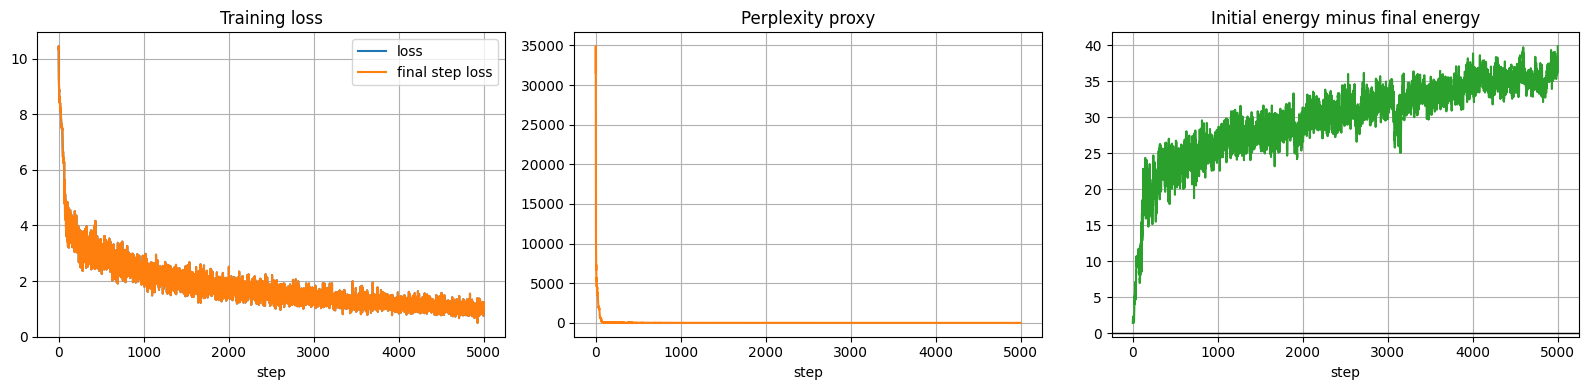

In [18]:
if len(history["loss"]) == 0:
    print("No training history yet. Train or load a checkpoint first.")
else:
    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    ax[0].plot(history["loss"], label="loss")
    ax[0].plot(history["final_step_loss"], label="final step loss")
    ax[0].set_title("Training loss")
    ax[0].set_xlabel("step")
    ax[0].legend()

    ax[1].plot(history["perplexity"], color="tab:orange")
    ax[1].set_title("Perplexity proxy")
    ax[1].set_xlabel("step")

    ax[2].plot(history["energy_gap"], color="tab:green")
    ax[2].axhline(0, color="black", linewidth=1)
    ax[2].set_title("Initial energy minus final energy")
    ax[2].set_xlabel("step")
    plt.tight_layout()

## Inspect Energy Refinement on One Example

This is the core EBT visualization. The same input sequence is passed through the model, and the predicted energy is collected at each MCMC refinement step.

If the EBT has learned a useful landscape, later refinement steps should often have lower or more structured energy. That does not prove reasoning correctness. It only shows that the model has learned an internal compatibility surface.

step 0 top tokens:  Question  Question  running  no  ter  there  there pa  had  36  money  money  tomatoes  to  tomatoes  his  his  tomatoes  his  he  came  ended  into  tomatoes  his  he  came  36  distributed  his  tomatoes  his  his  many  tomatoes  did  did  his  abs  tomatoes
step 1 top tokens:  books  series  math  five  school ,  Grand pa  had  counted  36  more  shooting . .  on  vacation .  After  he  came  back  from  tomatoes  to  he  can  36  more  more  tomatoes .  If  many  tomatoes  grew  in  his ence ence
step 2 top tokens: ny  has  Nicole  a  spelling ,  Grand pa  had  counted  36  tomatoes  tomatoes .  going  on  Tuesday .  When  he  came  back  from  tomatoes ,  he  counted  the  times  more  tomatoes .  If  many  tomatoes  did  in  his ence ence
step 3 top tokens:  Question :  A  a  garden ,  Grand pa  had  counted  36  tomatoes  tomatoes ,  going  on  vacation .  When  he  counted  back  from  tomatoes ,  he  counted  36  times  more  tomatoes .  If  many  tomatoes

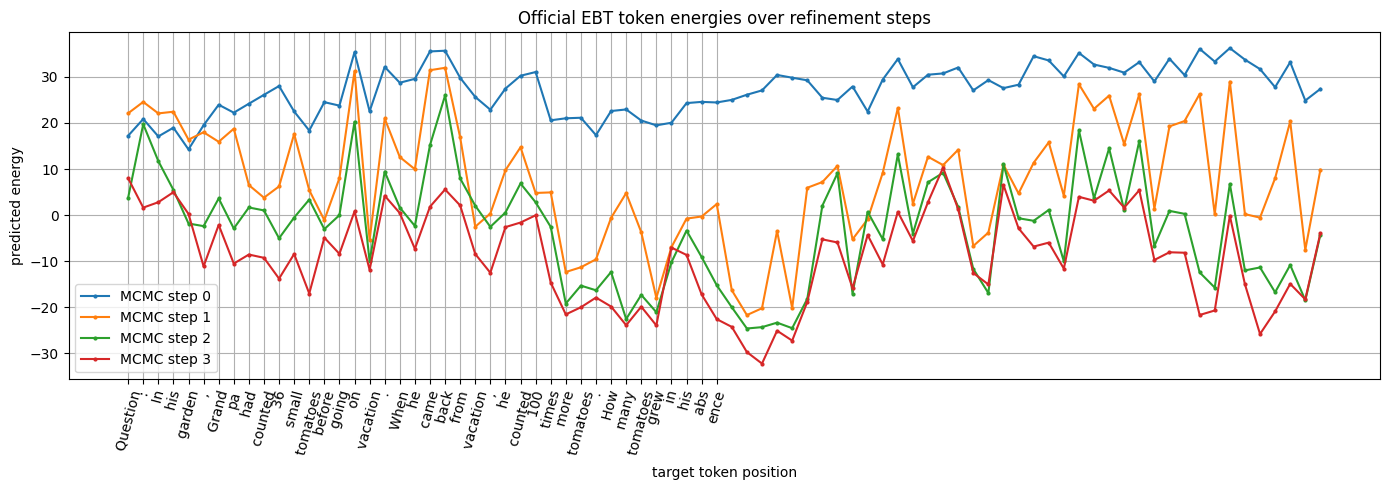

In [19]:
def inspect_sequence(text):
    model.eval()
    ids = encode_lines([text]).to(device)
    input_ids = ids.squeeze(1)[:, :-1]
    target_ids = ids.squeeze(1)[:, 1:]
    with torch.enable_grad():
        pred_logits, energies = model(input_ids, learning=False, return_raw_logits=True, no_randomness=True)
    tokens = [tokenizer.decode([int(t)]) for t in target_ids[0].detach().cpu()]
    energy_by_step = [e.detach().reshape(input_ids.shape[0], input_ids.shape[1]).cpu().numpy()[0] for e in energies]
    top_tokens_by_step = []
    for logits in pred_logits:
        top_ids = logits.detach()[0].argmax(dim=-1).cpu().tolist()
        top_tokens_by_step.append([tokenizer.decode([int(t)]) for t in top_ids])
    return tokens, energy_by_step, top_tokens_by_step

probe = texts[0]
tokens, energy_by_step, top_tokens_by_step = inspect_sequence(probe)

for step, top_tokens in enumerate(top_tokens_by_step):
    print(f"step {step} top tokens:", " ".join(top_tokens[:40]))

plt.figure(figsize=(14, 5))
for step, energies in enumerate(energy_by_step):
    plt.plot(energies[:80], marker="o", markersize=2, label=f"MCMC step {step}")
plt.xticks(range(min(len(tokens), 40)), tokens[:40], rotation=75)
plt.title("Official EBT token energies over refinement steps")
plt.xlabel("target token position")
plt.ylabel("predicted energy")
plt.legend()
plt.tight_layout()

## BTR/T^3 Evaluation Dataset

This is the missing experimental layer: instead of scoring one hand-written sample, we build paired variants from many GSM8K examples.

For each original trace, the notebook creates:

- `informative_prefix`: the question plus the early useful part of the solution. This is the prefix we want to preserve.
- `redundant_tail_btr`: the same prefix followed by repeated no-progress statements. This is the synthetic belief-trap tail.
- `intervention_wrong`: the question is counterfactually changed, but the original solution is kept. This is plausible-looking text that should be wrong under intervention.

The key test is whether EBT energy separates `redundant_tail_btr` from `intervention_wrong`. If it cannot, the model is mostly ranking dataset plausibility. If it can, energy features become a candidate signal for T^3-style truncation.

In [20]:
import re
import pandas as pd

_number_pattern = re.compile(r"-?\d+(?:,\d{3})*(?:\.\d+)?")

def split_answer_steps(answer):
    clean = answer.strip()
    if "####" in clean:
        reasoning, final = clean.split("####", 1)
        final = "####" + final.strip()
    else:
        reasoning, final = clean, ""
    steps = [line.strip() for line in reasoning.splitlines() if line.strip()]
    if not steps:
        steps = [reasoning.strip()]
    return steps, final

def intervene_question(question):
    """Change the first numeric quantity in the question, creating a counterfactual problem."""
    def repl(match):
        raw = match.group(0)
        value = float(raw.replace(",", ""))
        if value == 0:
            new_value = 1
        elif value.is_integer():
            new_value = int(value) + max(1, int(abs(value) * 0.25))
        else:
            new_value = round(value * 1.25, 2)
        return str(new_value)
    changed, n = _number_pattern.subn(repl, question, count=1)
    if n == 0:
        changed = "Counterfactual version: " + question
    return changed

def build_btr_eval_records(dataset_rows, max_items=EVAL_EXAMPLES):
    records = []
    for example_id, ex in enumerate(dataset_rows.select(range(min(max_items, len(dataset_rows))))):
        question = ex["question"].strip()
        answer = ex["answer"].strip()
        steps, final = split_answer_steps(answer)
        split_idx = max(1, min(len(steps), int(np.ceil(len(steps) * 0.5))))
        prefix_steps = steps[:split_idx]
        prefix_text = "\n".join(prefix_steps)
        full_text = "\n".join(steps + ([final] if final else []))
        wrong_question = intervene_question(question)
        redundant_tail = "\n".join([
            "No new information is obtained.",
            "The agent repeats the same check and the hypothesis set does not shrink.",
            "No new information is obtained.",
            "The agent repeats the same check and the hypothesis set does not shrink.",
        ])

        variants = [
            dict(
                label="informative_prefix",
                btr_label=0,
                intervention_wrong=0,
                expected_role="preserve_credit",
                text=f"Question: {question}\nReasoning prefix: {prefix_text}",
            ),
            dict(
                label="redundant_tail_btr",
                btr_label=1,
                intervention_wrong=0,
                expected_role="truncate_tail",
                text=f"Question: {question}\nReasoning prefix: {prefix_text}\n{redundant_tail}",
            ),
            dict(
                label="intervention_wrong",
                btr_label=0,
                intervention_wrong=1,
                expected_role="verification_gap_probe",
                text=f"Question: {wrong_question}\nReasoning and answer: {full_text}",
            ),
        ]
        for variant in variants:
            variant.update(example_id=example_id, original_question=question, intervened_question=wrong_question)
            records.append(variant)
    return pd.DataFrame(records)

btr_eval_df = build_btr_eval_records(dataset, max_items=EVAL_EXAMPLES)
print(btr_eval_df["label"].value_counts())
btr_eval_df.head(6)

label
informative_prefix    64
redundant_tail_btr    64
intervention_wrong    64
Name: count, dtype: int64


,label,btr_label,intervention_wrong,expected_role,text,example_id,original_question,intervened_question
0,informative_prefix,0,0,preserve_credit,"Question: In his garden, Grandpa had counted 3...",0,"In his garden, Grandpa had counted 36 small to...","In his garden, Grandpa had counted 45 small to..."
1,redundant_tail_btr,1,0,truncate_tail,"Question: In his garden, Grandpa had counted 3...",0,"In his garden, Grandpa had counted 36 small to...","In his garden, Grandpa had counted 45 small to..."
2,intervention_wrong,0,1,verification_gap_probe,"Question: In his garden, Grandpa had counted 4...",0,"In his garden, Grandpa had counted 36 small to...","In his garden, Grandpa had counted 45 small to..."
3,informative_prefix,0,0,preserve_credit,Question: Tom's rabbit can run at 25 miles per...,1,Tom's rabbit can run at 25 miles per hour. Hi...,Tom's rabbit can run at 31 miles per hour. Hi...
4,redundant_tail_btr,1,0,truncate_tail,Question: Tom's rabbit can run at 25 miles per...,1,Tom's rabbit can run at 25 miles per hour. Hi...,Tom's rabbit can run at 31 miles per hour. Hi...
5,intervention_wrong,0,1,verification_gap_probe,Question: Tom's rabbit can run at 31 miles per...,1,Tom's rabbit can run at 25 miles per hour. Hi...,Tom's rabbit can run at 31 miles per hour. Hi...


## Score Labeled Variants With EBT Energy

For each variant, the notebook records several signals:

- `final_loss_energy`: next-token loss at the final EBT refinement step. This is a practical energy proxy for the whole text.
- `energy_gap`: initial predicted energy minus final predicted energy from the official EBT metrics.
- `mcmc_energy_*`: direct mean predicted energy at each EBT refinement step.
- `mcmc_plateau`: the final two refinement steps changed by less than `ENERGY_PLATEAU_EPS`.
- `mcmc_reversal`: the final refinement energy is higher than the initial refinement energy.
- `truncate_signal`: plateau or reversal. This is the first candidate T^3-style signal.

This is not yet a trained classifier. It is a measurement layer that asks whether energy dynamics contain useful truncation information.

In [21]:
def ebt_energy_trace(text):
    model.eval()
    ids = encode_lines([text]).to(device)
    input_ids = ids.squeeze(1)[:, :-1]
    with torch.enable_grad():
        _, energies = model(input_ids, learning=False, return_raw_logits=True, no_randomness=True)
    return [float(e.detach().reshape(input_ids.shape[0], input_ids.shape[1]).mean().cpu()) for e in energies]

def score_one_variant(row):
    model.eval()
    batch = {"input_ids": encode_lines([row["text"]]).to(device)}
    with torch.enable_grad():
        metrics = model.forward_loss_wrapper(batch, phase="eval")
    trace = ebt_energy_trace(row["text"])
    final_delta = abs(trace[-1] - trace[-2]) if len(trace) >= 2 else 0.0
    mcmc_reversal = trace[-1] > trace[0] if len(trace) >= 2 else False
    mcmc_plateau = final_delta < ENERGY_PLATEAU_EPS
    return {
        "final_loss_energy": float(metrics["final_step_loss"].detach().cpu()),
        "initial_loss": float(metrics["initial_loss"].detach().cpu()),
        "energy_gap": float(metrics["initial_final_pred_energies_gap"].detach().cpu()),
        "mcmc_energy_initial": trace[0],
        "mcmc_energy_final": trace[-1],
        "mcmc_energy_trace": trace,
        "mcmc_final_delta_abs": final_delta,
        "mcmc_plateau": bool(mcmc_plateau),
        "mcmc_reversal": bool(mcmc_reversal),
        "truncate_signal": bool(mcmc_plateau or mcmc_reversal),
    }

scored_rows = []
for i, row in btr_eval_df.iterrows():
    scored = score_one_variant(row)
    scored_rows.append({**row.to_dict(), **scored})
    if (i + 1) % 10 == 0 or i == len(btr_eval_df) - 1:
        print(f"scored {i + 1}/{len(btr_eval_df)}")

btr_scores = pd.DataFrame(scored_rows)
btr_scores.to_csv(ARTIFACT_DIR / f"btr_t3_eval_scores_{COMPUTE_PRESET}.csv", index=False)
btr_scores.head()

scored 10/192
scored 20/192
scored 30/192
scored 40/192
scored 50/192
scored 60/192
scored 70/192
scored 80/192
scored 90/192
scored 100/192
scored 110/192
scored 120/192
scored 130/192
scored 140/192
scored 150/192
scored 160/192
scored 170/192
scored 180/192
scored 190/192
scored 192/192


,label,btr_label,intervention_wrong,expected_role,text,example_id,original_question,intervened_question,final_loss_energy,initial_loss,energy_gap,mcmc_energy_initial,mcmc_energy_final,mcmc_energy_trace,mcmc_final_delta_abs,mcmc_plateau,mcmc_reversal,truncate_signal
0,informative_prefix,0,0,preserve_credit,"Question: In his garden, Grandpa had counted 3...",0,"In his garden, Grandpa had counted 36 small to...","In his garden, Grandpa had counted 45 small to...",0.817030,1.375592,42.204376,24.079353,-18.126108,"[24.07935333251953, -11.670951843261719, -16.3...",1.783007,False,False,False
1,redundant_tail_btr,1,0,truncate_tail,"Question: In his garden, Grandpa had counted 3...",0,"In his garden, Grandpa had counted 36 small to...","In his garden, Grandpa had counted 45 small to...",3.406191,3.352236,40.114826,26.585983,-13.537674,"[26.585983276367188, -5.400668144226074, -10.8...",2.659627,False,False,False
2,intervention_wrong,0,1,verification_gap_probe,"Question: In his garden, Grandpa had counted 4...",0,"In his garden, Grandpa had counted 36 small to...","In his garden, Grandpa had counted 45 small to...",0.434065,1.528066,42.638832,25.896351,-16.740602,"[25.896350860595703, -9.29196548461914, -14.80...",1.935816,False,False,False
3,informative_prefix,0,0,preserve_credit,Question: Tom's rabbit can run at 25 miles per...,1,Tom's rabbit can run at 25 miles per hour. Hi...,Tom's rabbit can run at 31 miles per hour. Hi...,1.295381,1.718933,39.152832,24.085449,-15.071096,"[24.08544921875, -9.571493148803711, -13.63082...",1.440272,False,False,False
4,redundant_tail_btr,1,0,truncate_tail,Question: Tom's rabbit can run at 25 miles per...,1,Tom's rabbit can run at 25 miles per hour. Hi...,Tom's rabbit can run at 31 miles per hour. Hi...,4.015073,3.702558,37.683464,25.168049,-12.524946,"[25.168048858642578, -5.355524063110352, -10.6...",1.912600,False,False,False


## Aggregate Separation Test

This is the core test you described.

For each GSM8K example, compare the three matched variants:

- Should `informative_prefix` generally score better than `redundant_tail_btr`?
- Should `informative_prefix` generally score better than `intervention_wrong`?
- Can the model distinguish `redundant_tail_btr` from `intervention_wrong`?

If `intervention_wrong` often receives energy as low as or lower than the redundant BTR tail, that is evidence of the verification gap: the EBT is rewarding plausibility under the dataset rather than causal correctness under intervention.

                    final_loss_energy  initial_loss  energy_gap  \
label                                                             
intervention_wrong           1.144661      2.453611   37.564700   
informative_prefix           1.291762      2.029677   38.262486   
redundant_tail_btr           3.815909      3.908787   35.795449   

                    mcmc_energy_initial  mcmc_energy_final  \
label                                                        
intervention_wrong            25.466529         -12.100196   
informative_prefix            24.546650         -13.716084   
redundant_tail_btr            25.843553          -9.951195   

                    mcmc_final_delta_abs  truncate_signal  
label                                                      
intervention_wrong              2.114155              0.0  
informative_prefix              1.805753              0.0  
redundant_tail_btr              2.467598              0.0  

paired separation rates
good_lt_tail     1.00000
goo

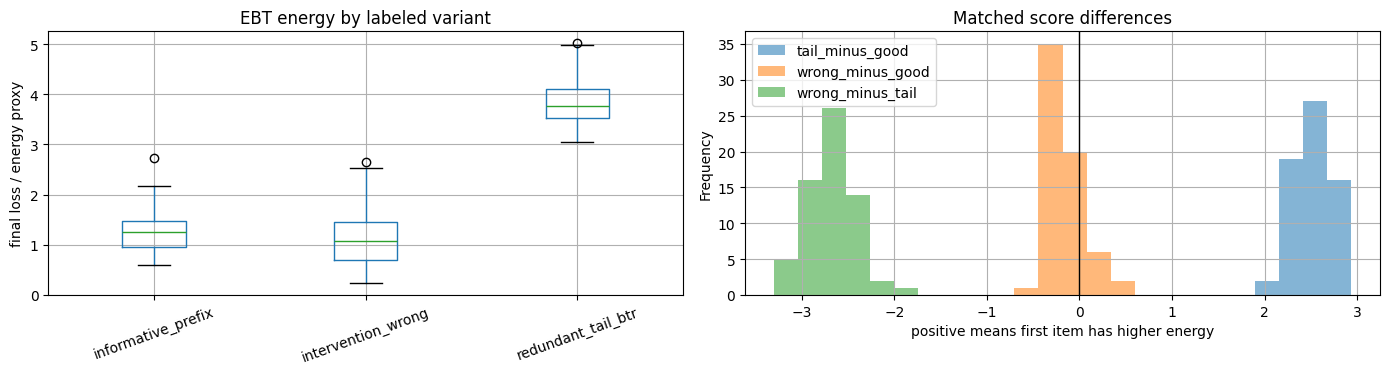

In [22]:
summary = btr_scores.groupby("label")[[
    "final_loss_energy",
    "initial_loss",
    "energy_gap",
    "mcmc_energy_initial",
    "mcmc_energy_final",
    "mcmc_final_delta_abs",
    "truncate_signal",
]].mean().sort_values("final_loss_energy")
print(summary)

def paired_rates(df):
    rows = []
    for example_id, group in df.groupby("example_id"):
        by_label = group.set_index("label")
        if {"informative_prefix", "redundant_tail_btr", "intervention_wrong"}.issubset(by_label.index):
            good = by_label.loc["informative_prefix", "final_loss_energy"]
            tail = by_label.loc["redundant_tail_btr", "final_loss_energy"]
            wrong = by_label.loc["intervention_wrong", "final_loss_energy"]
            rows.append({
                "example_id": example_id,
                "good_lt_tail": good < tail,
                "good_lt_wrong": good < wrong,
                "wrong_lt_tail": wrong < tail,
                "wrong_lt_good": wrong < good,
                "tail_minus_good": tail - good,
                "wrong_minus_good": wrong - good,
                "wrong_minus_tail": wrong - tail,
            })
    return pd.DataFrame(rows)

paired = paired_rates(btr_scores)
print("\npaired separation rates")
print(paired[["good_lt_tail", "good_lt_wrong", "wrong_lt_tail", "wrong_lt_good"]].mean())

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
btr_scores.boxplot(column="final_loss_energy", by="label", ax=ax[0], rot=20)
ax[0].set_title("EBT energy by labeled variant")
ax[0].set_xlabel("")
ax[0].set_ylabel("final loss / energy proxy")

paired[["tail_minus_good", "wrong_minus_good", "wrong_minus_tail"]].plot(kind="hist", bins=24, alpha=0.55, ax=ax[1])
ax[1].axvline(0, color="black", linewidth=1)
ax[1].set_title("Matched score differences")
ax[1].set_xlabel("positive means first item has higher energy")
plt.suptitle("")
plt.tight_layout()

## Turn-Level T^3 Truncation Proxy

The previous section scores complete variants. T^3 is about stopping a rollout when progress stalls.

This cell builds an incremental trajectory from one GSM8K solution: useful solution lines first, then repeated redundant BTR lines. It scores each prefix and detects the first turn where energy progress plateaus or reverses.

This is a proxy for:

`stop when energy improvement is too small for a window, or when energy starts getting worse.`

T^3 proxy stop turn: 3
   turn  final_loss_energy  energy_improvement  energy_gap  t3_stop
0     1           0.745545                 NaN   39.731148    False
1     2           0.817759           -0.072214   42.201279    False
2     3           0.894109           -0.076351   43.320656     True
3     4           0.884867            0.009242   43.611134    False
4     5           2.045131           -1.160264   42.838558    False
5     6           3.032118           -0.986987   40.829647    False
6     7           4.009344           -0.977226   38.090317    False
7     8           4.945858           -0.936514   34.854847    False
8     9           5.893925           -0.948067   31.559994    False


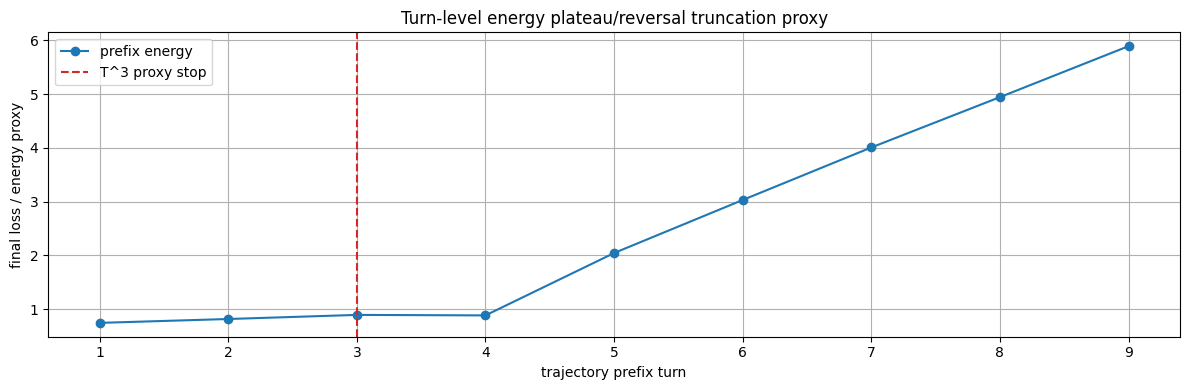

In [23]:
def build_incremental_trace(example, redundant_repeats=5):
    question = example["question"].strip()
    steps, final = split_answer_steps(example["answer"].strip())
    turns = [f"Question: {question}\nReasoning prefix: " + "\n".join(steps[:i]) for i in range(1, len(steps) + 1)]
    if final:
        turns.append(f"Question: {question}\nReasoning prefix: " + "\n".join(steps + [final]))
    for i in range(redundant_repeats):
        turns.append(turns[-1] + "\nNo new information is obtained. The hypothesis set does not shrink.")
    return turns

def score_turn_sequence(turn_texts):
    rows = []
    for t, text in enumerate(turn_texts, start=1):
        row = {"text": text}
        row.update(score_one_variant(row))
        row["turn"] = t
        rows.append(row)
    out = pd.DataFrame(rows)
    out["energy_improvement"] = -out["final_loss_energy"].diff()
    out.loc[out.index[0], "energy_improvement"] = np.nan
    plateau_flags = out["energy_improvement"].abs() < TURN_PLATEAU_EPS
    reversal_flags = out["energy_improvement"] < 0
    stop_turn = None
    for i in range(TURN_PLATEAU_WINDOW, len(out)):
        recent_plateau = plateau_flags.iloc[i - TURN_PLATEAU_WINDOW + 1:i + 1].all()
        if recent_plateau or reversal_flags.iloc[i]:
            stop_turn = int(out.iloc[i]["turn"])
            break
    out["t3_stop"] = out["turn"] == stop_turn
    return out, stop_turn

trace_example = dataset[0]
turn_texts = build_incremental_trace(trace_example, redundant_repeats=5)
turn_scores, stop_turn = score_turn_sequence(turn_texts)
print("T^3 proxy stop turn:", stop_turn)
print(turn_scores[["turn", "final_loss_energy", "energy_improvement", "energy_gap", "t3_stop"]])

plt.figure(figsize=(12, 4))
plt.plot(turn_scores["turn"], turn_scores["final_loss_energy"], marker="o", label="prefix energy")
if stop_turn is not None:
    plt.axvline(stop_turn, color="tab:red", linestyle="--", label="T^3 proxy stop")
plt.xlabel("trajectory prefix turn")
plt.ylabel("final loss / energy proxy")
plt.title("Turn-level energy plateau/reversal truncation proxy")
plt.legend()
plt.tight_layout()

## Failure Analysis: Verification Gap Cases

This is the most important diagnostic for your thesis.

A failure case is an `intervention_wrong` trajectory that receives energy at least as good as a matched redundant-tail trajectory, or even as good as the informative prefix. Those examples show that the EBT is not mediating causality; it is scoring compatibility with its learned distribution.

In [24]:
try:
    from IPython.display import display
except Exception:
    display = print

failure_rows = []
for example_id, group in btr_scores.groupby("example_id"):
    by_label = group.set_index("label")
    if {"informative_prefix", "redundant_tail_btr", "intervention_wrong"}.issubset(by_label.index):
        good = by_label.loc["informative_prefix"]
        tail = by_label.loc["redundant_tail_btr"]
        wrong = by_label.loc["intervention_wrong"]
        if wrong["final_loss_energy"] <= tail["final_loss_energy"] or wrong["final_loss_energy"] <= good["final_loss_energy"]:
            failure_rows.append({
                "example_id": example_id,
                "wrong_energy": wrong["final_loss_energy"],
                "tail_energy": tail["final_loss_energy"],
                "good_energy": good["final_loss_energy"],
                "wrong_minus_tail": wrong["final_loss_energy"] - tail["final_loss_energy"],
                "wrong_minus_good": wrong["final_loss_energy"] - good["final_loss_energy"],
                "original_question": wrong["original_question"],
                "intervened_question": wrong["intervened_question"],
                "wrong_text": wrong["text"],
            })

failures = pd.DataFrame(failure_rows).sort_values(["wrong_minus_good", "wrong_minus_tail"])
print(f"failure cases: {len(failures)} / {btr_scores['example_id'].nunique()}")
if len(failures):
    display(failures[["example_id", "wrong_energy", "tail_energy", "good_energy", "wrong_minus_tail", "wrong_minus_good"]].head(10))
    first = failures.iloc[0]
    print("\noriginal question:\n", first["original_question"])
    print("\nintervened question:\n", first["intervened_question"])
    print("\nwrong continuation scored too highly:\n", first["wrong_text"][:1200])
else:
    print("No verification-gap failures under this threshold. Try increasing EVAL_EXAMPLES or using harder interventions.")

failure cases: 64 / 64


,example_id,wrong_energy,tail_energy,good_energy,wrong_minus_tail,wrong_minus_good
3,3,0.382485,3.682292,0.844644,-3.299807,-0.462160
24,24,0.986643,4.112179,1.405869,-3.125536,-0.419226
57,57,0.756796,3.527719,1.162990,-2.770923,-0.406194
61,61,0.584626,3.349158,0.973746,-2.764532,-0.389121
0,0,0.434065,3.406191,0.817030,-2.972126,-0.382964
41,41,1.090143,3.403891,1.457480,-2.313748,-0.367337
27,27,0.801227,3.610099,1.160761,-2.808871,-0.359533
32,32,0.236092,3.224185,0.588138,-2.988093,-0.352045
4,4,0.456635,3.549449,0.795240,-3.092814,-0.338605
53,53,0.384034,3.071944,0.711665,-2.687910,-0.327631



original question:
 John and Anna bought some eBook readers. John bought 15 eBook readers less than Anna did. Unfortunately, John lost 3 eBook readers. If Anna bought 50 eBook readers, how many eBook readers do they have altogether?

intervened question:
 John and Anna bought some eBook readers. John bought 18 eBook readers less than Anna did. Unfortunately, John lost 3 eBook readers. If Anna bought 50 eBook readers, how many eBook readers do they have altogether?

wrong continuation scored too highly:
 Question: John and Anna bought some eBook readers. John bought 18 eBook readers less than Anna did. Unfortunately, John lost 3 eBook readers. If Anna bought 50 eBook readers, how many eBook readers do they have altogether?
Reasoning and answer: John bought 50-15 = <<50-15=35>>35 eBook readers.
John has 35-3 = <<35-3=32>>32 eBook readers after losing some.
Together they have 50+32 = <<50+32=82>>82 eBook readers.
####82


## Interpretation


- It labels informative prefixes, redundant BTR tails, and interventionally wrong continuations.
- It defines truncation proxies from energy plateau and energy reversal.
- It compares the labels across many matched GSM8K examples.
- It surfaces cases where the EBT gives a wrong counterfactual continuation low energy.

The conclusion should be based on the paired rates and failure table:

- If `good_lt_tail` is high, EBT energy may help detect redundant tails.
- If `wrong_lt_tail` or `wrong_lt_good` is high, the verification gap is present.
- If plateau/reversal aligns with redundant tails, energy dynamics are a candidate T^3 signal.

